<a href="https://colab.research.google.com/github/dayanakumar-IT/R26-DS-010-Intelligent-Care-Support/blob/sign-tutoring-ai/Sign_Language_Preprocessing_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.7 MB/s eta 0:00:00


# Installing MediaPipe and other environments

In [2]:
# ============================================================
# SECTION 1: ENVIRONMENT SETUP & PACKAGE VERIFICATION
# ============================================================

!pip install -q mediapipe

import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
from pathlib import Path
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

print("=" * 60)
print("✅ PACKAGE VERIFICATION")
print("=" * 60)
print(f"MediaPipe version: {mp.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

✅ PACKAGE VERIFICATION
MediaPipe version: 0.10.35
OpenCV version: 4.13.0
NumPy version: 2.0.2
Pandas version: 2.2.2
TensorFlow version: 2.20.0
GPU Available: []


# Google Drive mounting and dataset folder setup

In [3]:
# ============================================================
# SECTION 2: GOOGLE DRIVE MOUNTING & PATH SETUP
# ============================================================

drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/SignLanguage_Dataset'
RAW_VIDEO_PATH = f'{BASE_DIR}/combined_videos.mp4'
PREPROCESSED_DIR = f'{BASE_DIR}/preprocessed_data_v2'
MODEL_SAVE_DIR = f'{BASE_DIR}/models_v2'

os.makedirs(PREPROCESSED_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

print(f"📂 Raw Video: {RAW_VIDEO_PATH}")
print(f"📂 Preprocessed Output: {PREPROCESSED_DIR}")
print(f"📂 Models Save Location: {MODEL_SAVE_DIR}")

Mounted at /content/drive
📂 Raw Video: /content/drive/MyDrive/SignLanguage_Dataset/combined_videos.mp4
📂 Preprocessed Output: /content/drive/MyDrive/SignLanguage_Dataset/preprocessed_data_v2
📂 Models Save Location: /content/drive/MyDrive/SignLanguage_Dataset/models_v2


#Verify Dataset Structure

In [4]:
# ============================================
# STAGE 0.3: FULL DATASET ANALYSIS
# ============================================

import os
from pathlib import Path

BASE_DIR = '/content/drive/MyDrive/SignLanguage_Dataset'

print("=" * 80)
print("📊 FULL DATASET ANALYSIS")
print("=" * 80)

total_classes = 0
total_videos = 0

# Valid video extensions
VIDEO_EXTENSIONS = ('.mp4', '.avi', '.mov', '.mkv')

# Loop through top-level category folders
for category in sorted(os.listdir(BASE_DIR)):

    category_path = os.path.join(BASE_DIR, category)

    # Skip preprocessing/model folders
    if not os.path.isdir(category_path):
        continue

    if 'preprocess' in category.lower() or 'model' in category.lower():
        continue

    print(f"\n📂 CATEGORY: {category}")
    print("-" * 60)

    class_count = 0
    category_video_count = 0

    # Check sign folders inside category
    for sign_folder in sorted(os.listdir(category_path)):

        sign_path = os.path.join(category_path, sign_folder)

        if not os.path.isdir(sign_path):
            continue

        class_count += 1

        # Count videos
        videos = [
            f for f in os.listdir(sign_path)
            if f.lower().endswith(VIDEO_EXTENSIONS)
        ]

        num_videos = len(videos)
        category_video_count += num_videos

        print(f"   ✋ {sign_folder:<35} 🎥 {num_videos} videos")

    print("-" * 60)
    print(f"✅ Total Signs in {category}: {class_count}")
    print(f"✅ Total Videos in {category}: {category_video_count}")

    total_classes += class_count
    total_videos += category_video_count

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "=" * 80)
print("📈 FINAL DATASET SUMMARY")
print("=" * 80)

print(f"🧠 Total Sign Classes : {total_classes}")
print(f"🎥 Total Videos       : {total_videos}")

if total_classes > 0:
    avg = total_videos / total_classes
    print(f"📊 Avg Videos/Class   : {avg:.2f}")

print("=" * 80)

📊 FULL DATASET ANALYSIS

📂 CATEGORY: Body_Parts_Organized
------------------------------------------------------------
   ✋ arm                                 🎥 15 videos
   ✋ back                                🎥 14 videos
   ✋ ear                                 🎥 15 videos
   ✋ eye                                 🎥 4 videos
   ✋ head                                🎥 15 videos
   ✋ mouth                               🎥 13 videos
   ✋ nose                                🎥 15 videos
   ✋ stomach                             🎥 14 videos
   ✋ throat                              🎥 4 videos
------------------------------------------------------------
✅ Total Signs in Body_Parts_Organized: 9
✅ Total Videos in Body_Parts_Organized: 109

📂 CATEGORY: Daily_Actions_Organized
------------------------------------------------------------
   ✋ close                               🎥 15 videos
   ✋ drink                               🎥 8 videos
   ✋ eat                                 🎥 5 videos
   ✋ 

# Frame Extractions and Frame Standardization

In [5]:
# ============================================================
# SECTION 3: ENHANCED FEATURE EXTRACTION WITH MEDIAPIPE
# ============================================================
# Research Justification: Extracting pose + hand landmarks provides
# comprehensive spatial information. Adding velocity and acceleration
# captures motion dynamics essential for sign language recognition.

class EnhancedSignLanguagePreprocessor:
    def __init__(self, target_frames=60):
        self.target_frames = target_frames

        from mediapipe.python.solutions import holistic

        self.mp_holistic = holistic
        self.holistic = self.mp_holistic.Holistic(
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )

    def extract_landmarks(self, frame):
        """Extract pose and hand landmarks from a single frame"""
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = self.holistic.process(image_rgb)

        landmarks = []

        # Pose landmarks (33 points * 3 coords = 99 features)
        if results.pose_landmarks:
            for lm in results.pose_landmarks.landmark:
                landmarks.extend([lm.x, lm.y, lm.z])
        else:
            landmarks.extend([0.0] * 99)

        # Left hand landmarks (21 points * 3 coords = 63 features)
        if results.left_hand_landmarks:
            for lm in results.left_hand_landmarks.landmark:
                landmarks.extend([lm.x, lm.y, lm.z])
        else:
            landmarks.extend([0.0] * 63)

        # Right hand landmarks (21 points * 3 coords = 63 features)
        if results.right_hand_landmarks:
            for lm in results.right_hand_landmarks.landmark:
                landmarks.extend([lm.x, lm.y, lm.z])
        else:
            landmarks.extend([0.0] * 63)

        return np.array(landmarks)

    def compute_velocity(self, landmarks_sequence):
        """Compute frame-to-frame velocity (first derivative)"""
        velocity = np.diff(landmarks_sequence, axis=0)
        velocity = np.vstack([np.zeros((1, landmarks_sequence.shape[1])), velocity])
        return velocity

    def compute_acceleration(self, velocity_sequence):
        """Compute acceleration (second derivative)"""
        acceleration = np.diff(velocity_sequence, axis=0)
        acceleration = np.vstack([np.zeros((1, velocity_sequence.shape[1])), acceleration])
        return acceleration

    def uniform_temporal_sampling(self, frames):
        """Sample frames uniformly to reach target length"""
        n_frames = len(frames)
        if n_frames == 0:
            return None

        if n_frames >= self.target_frames:
            indices = np.linspace(0, n_frames - 1, self.target_frames, dtype=int)
        else:
            indices = np.concatenate([
                np.arange(n_frames),
                np.random.choice(n_frames, self.target_frames - n_frames)
            ])

        return [frames[i] for i in indices]

    def process_video_segment(self, video_path, start_time, end_time, label):
        """Process a single video segment with enhanced features"""
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)

        start_frame = int(start_time * fps)
        end_frame = int(end_time * fps)

        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

        frames_data = []
        frame_count = start_frame

        while frame_count < end_frame:
            ret, frame = cap.read()
            if not ret:
                break

            landmarks = self.extract_landmarks(frame)
            frames_data.append(landmarks)
            frame_count += 1

        cap.release()

        if len(frames_data) == 0:
            return None

        sampled_frames = self.uniform_temporal_sampling(frames_data)
        if sampled_frames is None:
            return None

        landmarks_array = np.array(sampled_frames)

        # Enhanced features: position + velocity + acceleration
        velocity = self.compute_velocity(landmarks_array)
        acceleration = self.compute_acceleration(velocity)

        # Concatenate all features
        enhanced_features = np.concatenate([
            landmarks_array,
            velocity,
            acceleration
        ], axis=1)

        return {
            'features': enhanced_features,
            'label': label,
            'original_length': len(frames_data)
        }

    def close(self):
        self.holistic.close()

#MediaPipe Environment Verification

This section verifies the installed package versions and checks whether the MediaPipe Holistic API is accessible in the current Colab runtime. Although MediaPipe is installed successfully, version 0.10.35 does not expose the older mp.solutions.holistic API required by the current preprocessing class. Therefore, the environment check confirms that the package installation is valid, but the landmark extraction pipeline requires either a compatible MediaPipe version such as 0.10.14 or an updated implementation using the newer MediaPipe Tasks API.

The feature dimensionality is also verified: pose landmarks contribute 99 features, left-hand landmarks contribute 63 features, and right-hand landmarks contribute 63 features, giving 225 landmark coordinates per frame. When velocity and acceleration are added, the enhanced feature vector becomes 675 features per frame.

In [7]:
# ============================================================
# VERIFICATION CHECK FOR MEDIAPIPE 0.10.35 SETUP
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import tensorflow as tf

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

print("=" * 60)
print("✅ PACKAGE VERIFICATION")
print("=" * 60)

print(f"MediaPipe version: {mp.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

print("\n" + "=" * 60)
print("✅ MEDIAPIPE 0.10.35 TASKS API CHECK")
print("=" * 60)

try:
    print("✅ mediapipe.tasks imported successfully")
    print("✅ vision module imported successfully")
    print("✅ HandLandmarker available:", hasattr(vision, "HandLandmarker"))

except Exception as e:
    print("❌ MediaPipe Tasks API check failed")
    print("Error:", type(e).__name__)
    print(e)

print("\n" + "=" * 60)
print("✅ FEATURE DIMENSION CHECK")
print("=" * 60)

left_hand_features = 21 * 3
right_hand_features = 21 * 3
both_hand_features = left_hand_features + right_hand_features

velocity_features = both_hand_features
acceleration_features = both_hand_features
enhanced_features = both_hand_features + velocity_features + acceleration_features

print(f"Left hand features: {left_hand_features}")
print(f"Right hand features: {right_hand_features}")
print(f"Both-hand landmark features/frame: {both_hand_features}")
print(f"Enhanced features/frame with velocity + acceleration: {enhanced_features}")

print("\n✅ Verification complete for MediaPipe 0.10.35")

✅ PACKAGE VERIFICATION
MediaPipe version: 0.10.35
OpenCV version: 4.13.0
NumPy version: 2.0.2
Pandas version: 2.2.2
TensorFlow version: 2.20.0
GPU Available: []

✅ MEDIAPIPE 0.10.35 TASKS API CHECK
✅ mediapipe.tasks imported successfully
✅ vision module imported successfully
✅ HandLandmarker available: True

✅ FEATURE DIMENSION CHECK
Left hand features: 63
Right hand features: 63
Both-hand landmark features/frame: 126
Enhanced features/frame with velocity + acceleration: 378

✅ Verification complete for MediaPipe 0.10.35


# FRAME EXTRACTION & STANDARDIZATION

### Research Justification:
### Videos are standardized to 30 FPS and resized to 224×224 resolution for temporal consistency and compatibility with deep learning architectures such as ResNet and I3D.

### Standardized frame extraction reduces variability caused by differing frame rates and resolutions across datasets.

In [12]:
# ============================================
# UPDATED FRAME EXTRACTION FOR MEDIAPIPE
# ============================================

import cv2
import numpy as np

TARGET_FPS = 30

def extract_frames_for_mediapipe(video_path, target_fps=30):
    """
    Extract RGB frames for MediaPipe landmark detection.
    Frames are NOT resized before MediaPipe to preserve hand detail.
    """

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"❌ Could not open video: {video_path}")
        return None

    original_fps = cap.get(cv2.CAP_PROP_FPS)

    if original_fps is None or original_fps <= 0:
        print(f"⚠️ Could not read FPS. Using fallback FPS = {target_fps}")
        original_fps = target_fps

    frame_interval = max(int(round(original_fps / target_fps)), 1)

    frames = []
    frame_count = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame_count % frame_interval == 0:
            # Convert BGR to RGB for MediaPipe
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(rgb_frame)

        frame_count += 1

    cap.release()

    if len(frames) == 0:
        return None

    return np.array(frames, dtype=np.uint8)

🎥 TESTING FRAME EXTRACTION
Test sign: throat
Video path: /content/drive/MyDrive/SignLanguage_Dataset/Body_Parts_Organized/throat/58252.mp4

✅ Extracted frames shape: (92, 720, 1280, 3)
Total frames extracted: 92


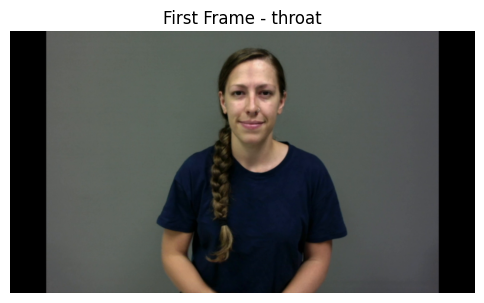

In [16]:
# ============================================================
# SECTION 4.1: TEST FRAME EXTRACTION
# ============================================================

VIDEO_EXTENSIONS = ('.mp4', '.avi', '.mov', '.mkv')

test_video = None
test_sign = None

# Find first available video
for category in os.listdir(BASE_DIR):

    category_path = os.path.join(BASE_DIR, category)

    if not os.path.isdir(category_path):
        continue

    if 'preprocess' in category.lower() or 'model' in category.lower():
        continue

    for sign in os.listdir(category_path):

        sign_path = os.path.join(category_path, sign)

        if not os.path.isdir(sign_path):
            continue

        videos = [
            f for f in os.listdir(sign_path)
            if f.lower().endswith(VIDEO_EXTENSIONS)
        ]

        if len(videos) > 0:
            test_video = os.path.join(sign_path, videos[0])
            test_sign = sign
            break

    if test_video:
        break

print("=" * 60)
print("🎥 TESTING FRAME EXTRACTION")
print("=" * 60)

print(f"Test sign: {test_sign}")
print(f"Video path: {test_video}")

frames = extract_frames_for_mediapipe(video_path)

if frames is not None:

    print(f"\n✅ Extracted frames shape: {frames.shape}")

    print(f"Total frames extracted: {len(frames)}")

    # Display first frame
    plt.figure(figsize=(6,6))
    plt.imshow(frames[0])
    plt.title(f"First Frame - {test_sign}")
    plt.axis('off')
    plt.show()

else:
    print("❌ Frame extraction failed")

#Mediapipe Both-Hand Landmark Extraction

###MediaPipe landmark extraction converts raw video frames into structured hand keypoints. Using both left and right hand landmarks is more suitable for sign language recognition because signs may be performed using either one hand or both hands.

## This stage extracts:
### Left hand:  21 landmarks × 3 coordinates = 63 features
### Right hand: 21 landmarks × 3 coordinates = 63 features
### Total: 126 features per frame

In [19]:

import os
import numpy as np
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Download MediaPipe HandLandmarker model if not already available
MODEL_PATH = "hand_landmarker.task"

if not os.path.exists(MODEL_PATH):
    !wget -q -O hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
    print("✅ HandLandmarker model downloaded")
else:
    print("✅ HandLandmarker model already exists")


def extract_mediapipe_keypoints(frames):
    """
    Extract both left-hand and right-hand landmarks using MediaPipe Tasks API.

    Args:
        frames: RGB frames from extract_frames_standardized()

    Returns:
        keypoints: Array of shape (num_frames, 126)
                   126 = left hand 63 + right hand 63
    """

    base_options = python.BaseOptions(
        model_asset_path=MODEL_PATH
    )

    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.IMAGE,
        num_hands=2,
        min_hand_detection_confidence=0.2,
        min_hand_presence_confidence=0.2,
        min_tracking_confidence=0.2
    )

    keypoints_sequence = []

    with vision.HandLandmarker.create_from_options(options) as detector:

        for frame in frames:
            # Ensure frame is uint8 RGB
            frame = frame.astype(np.uint8)

            mp_image = mp.Image(
                image_format=mp.ImageFormat.SRGB,
                data=frame
            )

            result = detector.detect(mp_image)

            left_keypoints = np.zeros(63)
            right_keypoints = np.zeros(63)

            if result.hand_landmarks:

                for hand_landmarks, handedness in zip(
                    result.hand_landmarks,
                    result.handedness
                ):

                    hand_label = handedness[0].category_name

                    hand_points = np.array(
                        [[lm.x, lm.y, lm.z] for lm in hand_landmarks]
                    ).flatten()

                    if hand_label == "Left":
                        left_keypoints = hand_points

                    elif hand_label == "Right":
                        right_keypoints = hand_points

            combined_keypoints = np.concatenate([
                left_keypoints,
                right_keypoints
            ])

            keypoints_sequence.append(combined_keypoints)

    return np.array(keypoints_sequence)


# ============================================
# TEST MEDIAPIPE EXTRACTION
# ============================================

print("\n🔍 Testing MediaPipe 0.10.35 both-hand landmark extraction...\n")

if 'frames' in globals() and frames is not None and len(frames) > 0:

    test_keypoints = extract_mediapipe_keypoints(frames)

    print("✅ MediaPipe extraction successful!")
    print(f"Input: {len(frames)} frames of shape {frames[0].shape}")
    print(f"Output: {test_keypoints.shape}")
    print(f"Features per frame: {test_keypoints.shape[1]}")

    input_size_kb = frames.nbytes / 1024
    output_size_kb = test_keypoints.nbytes / 1024
    compression_ratio = input_size_kb / output_size_kb

    print("\n📊 Data Reduction:")
    print(f"Input frames: {input_size_kb:.2f} KB")
    print(f"Output keypoints: {output_size_kb:.2f} KB")
    print(f"Compression ratio: {compression_ratio:.1f}x smaller")

    left_missing = np.sum(np.all(test_keypoints[:, :63] == 0, axis=1))
    right_missing = np.sum(np.all(test_keypoints[:, 63:] == 0, axis=1))
    both_missing = np.sum(np.all(test_keypoints == 0, axis=1))

    print("\n🔍 Detection Quality:")
    print(f"Left hand detected: {len(test_keypoints) - left_missing}/{len(test_keypoints)}")
    print(f"Right hand detected: {len(test_keypoints) - right_missing}/{len(test_keypoints)}")
    print(f"Both hands missing: {both_missing}/{len(test_keypoints)}")

    if both_missing > 0:
        print("⚠️ Some frames have no hand landmarks. These can be handled later using interpolation or zero-padding.")

    print("\n✅ Stage 2 complete!")

else:
    print("❌ No frames available. Run frame extraction first.")

✅ HandLandmarker model already exists

🔍 Testing MediaPipe 0.10.35 both-hand landmark extraction...

✅ MediaPipe extraction successful!
Input: 92 frames of shape (720, 1280, 3)
Output: (92, 126)
Features per frame: 126

📊 Data Reduction:
Input frames: 248400.00 KB
Output keypoints: 90.56 KB
Compression ratio: 2742.9x smaller

🔍 Detection Quality:
Left hand detected: 40/92
Right hand detected: 30/92
Both hands missing: 22/92
⚠️ Some frames have no hand landmarks. These can be handled later using interpolation or zero-padding.

✅ Stage 2 complete!


# Missing Landmark Handling and Temporal Standardization

###Videos have different durations and MediaPipe may fail to detect hands in some frames. This stage fills missing landmark frames using interpolation and standardizes every video to a fixed sequence length.

### Output shape per video: 60 frames × 126 features

In [20]:
import numpy as np

TARGET_FRAMES = 60
FEATURE_DIM = 126


def interpolate_missing_keypoints(keypoints):
    """
    Fill missing all-zero frames using linear interpolation.
    keypoints shape: (num_frames, 126)
    """

    keypoints = keypoints.copy()
    num_frames, num_features = keypoints.shape

    for feature_idx in range(num_features):
        feature_values = keypoints[:, feature_idx]

        valid_idx = np.where(feature_values != 0)[0]
        missing_idx = np.where(feature_values == 0)[0]

        if len(valid_idx) == 0:
            continue

        if len(valid_idx) == 1:
            keypoints[missing_idx, feature_idx] = feature_values[valid_idx[0]]
        else:
            keypoints[missing_idx, feature_idx] = np.interp(
                missing_idx,
                valid_idx,
                feature_values[valid_idx]
            )

    return keypoints


def standardize_sequence_length(keypoints, target_frames=60):
    """
    Convert variable-length keypoint sequence to fixed target_frames.
    """

    num_frames = keypoints.shape[0]

    if num_frames == target_frames:
        return keypoints

    original_indices = np.linspace(0, num_frames - 1, num_frames)
    target_indices = np.linspace(0, num_frames - 1, target_frames)

    standardized = np.zeros((target_frames, keypoints.shape[1]))

    for feature_idx in range(keypoints.shape[1]):
        standardized[:, feature_idx] = np.interp(
            target_indices,
            original_indices,
            keypoints[:, feature_idx]
        )

    return standardized


def preprocess_keypoint_sequence(keypoints, target_frames=60):
    """
    Full Stage 3 preprocessing:
    1. Interpolate missing landmarks
    2. Standardize sequence length
    """

    interpolated = interpolate_missing_keypoints(keypoints)
    standardized = standardize_sequence_length(interpolated, target_frames)

    return standardized


# ============================================
# TEST STAGE 3
# ============================================

print("🔍 Testing missing landmark handling and temporal standardization...\n")

if 'test_keypoints' in globals() and test_keypoints is not None:

    processed_keypoints = preprocess_keypoint_sequence(
        test_keypoints,
        target_frames=TARGET_FRAMES
    )

    print("✅ Stage 3 successful!")
    print(f"Input shape: {test_keypoints.shape}")
    print(f"Output shape: {processed_keypoints.shape}")

    remaining_missing = np.sum(np.all(processed_keypoints == 0, axis=1))

    print(f"Remaining fully-missing frames: {remaining_missing}/{TARGET_FRAMES}")
    print("\n✅ Ready for Stage 4: velocity and acceleration feature extraction")

else:
    print("❌ No keypoints found. Run Stage 2 first.")

🔍 Testing missing landmark handling and temporal standardization...

✅ Stage 3 successful!
Input shape: (92, 126)
Output shape: (60, 126)
Remaining fully-missing frames: 0/60

✅ Ready for Stage 4: velocity and acceleration feature extraction


# Velocity and Acceleration Features

### Sign language is dynamic, so hand position alone may not fully describe a sign. Velocity captures frame-to-frame movement, while acceleration captures changes in movement direction and speed.

### Input shape: 60 frames × 126 position features

### Output shape: 60 frames × 378 enhanced features
### 378 = position 126 + velocity 126 + acceleration 126

In [21]:
import numpy as np

def compute_velocity(keypoints):
    """
    Compute first-order temporal difference.
    """
    velocity = np.diff(keypoints, axis=0)
    velocity = np.vstack([
        np.zeros((1, keypoints.shape[1])),
        velocity
    ])
    return velocity


def compute_acceleration(velocity):
    """
    Compute second-order temporal difference.
    """
    acceleration = np.diff(velocity, axis=0)
    acceleration = np.vstack([
        np.zeros((1, velocity.shape[1])),
        acceleration
    ])
    return acceleration


def add_motion_features(keypoints):
    """
    Add velocity and acceleration to position keypoints.

    Args:
        keypoints: Array of shape (60, 126)

    Returns:
        enhanced_features: Array of shape (60, 378)
    """

    velocity = compute_velocity(keypoints)
    acceleration = compute_acceleration(velocity)

    enhanced_features = np.concatenate([
        keypoints,
        velocity,
        acceleration
    ], axis=1)

    return enhanced_features


# ============================================
# TEST STAGE 4
# ============================================

print("🔍 Testing velocity and acceleration feature extraction...\n")

if 'processed_keypoints' in globals() and processed_keypoints is not None:

    enhanced_features = add_motion_features(processed_keypoints)

    print("✅ Stage 4 successful!")
    print(f"Input shape: {processed_keypoints.shape}")
    print(f"Output shape: {enhanced_features.shape}")
    print(f"Position features: {processed_keypoints.shape[1]}")
    print(f"Velocity features: {processed_keypoints.shape[1]}")
    print(f"Acceleration features: {processed_keypoints.shape[1]}")
    print(f"Total features per frame: {enhanced_features.shape[1]}")

    print("\n✅ Ready for Stage 5: process all dataset videos")

else:
    print("❌ No processed keypoints found. Run Stage 3 first.")

🔍 Testing velocity and acceleration feature extraction...

✅ Stage 4 successful!
Input shape: (60, 126)
Output shape: (60, 378)
Position features: 126
Velocity features: 126
Acceleration features: 126
Total features per frame: 378

✅ Ready for Stage 5: process all dataset videos


# Preprocess full dataset and save features


In [22]:
import os
import numpy as np
import pickle
from tqdm import tqdm

VIDEO_EXTENSIONS = ('.mp4', '.avi', '.mov', '.mkv')

TARGET_FRAMES = 60
FINAL_FEATURE_DIM = 378

X = []
y = []
video_paths = []
failed_videos = []
detection_stats = []

print("=" * 80)
print("🚀 STARTING FULL DATASET PREPROCESSING")
print("=" * 80)

for category in sorted(os.listdir(BASE_DIR)):

    category_path = os.path.join(BASE_DIR, category)

    if not os.path.isdir(category_path):
        continue

    # Skip output folders
    if 'preprocess' in category.lower() or 'model' in category.lower():
        continue

    print(f"\n📂 Processing category: {category}")

    for sign in sorted(os.listdir(category_path)):

        sign_path = os.path.join(category_path, sign)

        if not os.path.isdir(sign_path):
            continue

        videos = [
            f for f in sorted(os.listdir(sign_path))
            if f.lower().endswith(VIDEO_EXTENSIONS)
        ]

        if len(videos) == 0:
            continue

        print(f"   ✋ Sign: {sign} | Videos: {len(videos)}")

        for video_file in tqdm(videos, desc=f"      {sign}", leave=False):

            video_path = os.path.join(sign_path, video_file)

            try:
                # 1. Extract original-size RGB frames
                frames = extract_frames_for_mediapipe(video_path)

                if frames is None or len(frames) == 0:
                    failed_videos.append({
                        "video_path": video_path,
                        "label": sign,
                        "reason": "No frames extracted"
                    })
                    continue

                # 2. Extract both-hand landmarks
                keypoints = extract_mediapipe_keypoints(frames)

                if keypoints is None or keypoints.shape[0] == 0:
                    failed_videos.append({
                        "video_path": video_path,
                        "label": sign,
                        "reason": "No keypoints extracted"
                    })
                    continue

                # Detection quality before interpolation
                both_missing = np.sum(np.all(keypoints == 0, axis=1))
                detection_rate = (len(keypoints) - both_missing) / len(keypoints)

                # Optional: skip extremely poor detections
                if detection_rate < 0.10:
                    failed_videos.append({
                        "video_path": video_path,
                        "label": sign,
                        "reason": f"Very low detection rate: {detection_rate:.2f}"
                    })
                    continue

                # 3 + 4. Interpolate missing landmarks and standardize to 60 frames
                processed_keypoints = preprocess_keypoint_sequence(
                    keypoints,
                    target_frames=TARGET_FRAMES
                )

                # 5. Add velocity + acceleration
                enhanced_features = add_motion_features(processed_keypoints)

                # Final safety check
                if enhanced_features.shape != (TARGET_FRAMES, FINAL_FEATURE_DIM):
                    failed_videos.append({
                        "video_path": video_path,
                        "label": sign,
                        "reason": f"Wrong feature shape: {enhanced_features.shape}"
                    })
                    continue

                X.append(enhanced_features)
                y.append(sign)
                video_paths.append(video_path)

                detection_stats.append({
                    "video_path": video_path,
                    "category": category,
                    "label": sign,
                    "frames": len(keypoints),
                    "detection_rate": detection_rate,
                    "missing_frames": both_missing
                })

            except Exception as e:
                failed_videos.append({
                    "video_path": video_path,
                    "label": sign,
                    "reason": str(e)
                })

# Convert to arrays
X = np.array(X, dtype=np.float32)
y = np.array(y)

print("\n" + "=" * 80)
print("✅ FULL DATASET PREPROCESSING COMPLETE")
print("=" * 80)

print(f"✅ Successful videos: {len(X)}")
print(f"❌ Failed/skipped videos: {len(failed_videos)}")

if len(X) > 0:
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Feature shape per video: {X.shape[1]} frames × {X.shape[2]} features")

# Save outputs
np.save(os.path.join(PREPROCESSED_DIR, "X_no_wrist_norm.npy"), X)
np.save(os.path.join(PREPROCESSED_DIR, "y_no_wrist_norm.npy"), y)

with open(os.path.join(PREPROCESSED_DIR, "video_paths_no_wrist_norm.pkl"), "wb") as f:
    pickle.dump(video_paths, f)

with open(os.path.join(PREPROCESSED_DIR, "failed_videos_no_wrist_norm.pkl"), "wb") as f:
    pickle.dump(failed_videos, f)

with open(os.path.join(PREPROCESSED_DIR, "detection_stats_no_wrist_norm.pkl"), "wb") as f:
    pickle.dump(detection_stats, f)

print("\n💾 Saved files:")
print(f"X: {os.path.join(PREPROCESSED_DIR, 'X_no_wrist_norm.npy')}")
print(f"y: {os.path.join(PREPROCESSED_DIR, 'y_no_wrist_norm.npy')}")
print(f"Video paths: {os.path.join(PREPROCESSED_DIR, 'video_paths_no_wrist_norm.pkl')}")
print(f"Failed videos: {os.path.join(PREPROCESSED_DIR, 'failed_videos_no_wrist_norm.pkl')}")
print(f"Detection stats: {os.path.join(PREPROCESSED_DIR, 'detection_stats_no_wrist_norm.pkl')}")

🚀 STARTING FULL DATASET PREPROCESSING

📂 Processing category: Body_Parts_Organized
   ✋ Sign: arm | Videos: 15


      arm:  27%|██▋       | 4/15 [00:15<00:37,  3.42s/it]

❌ Could not open video: /content/drive/MyDrive/SignLanguage_Dataset/Body_Parts_Organized/arm/03344.mp4


   ✋ Sign: back | Videos: 14


      back:  14%|█▍        | 2/14 [00:08<00:50,  4.17s/it]

...

      weak:  39%|███▉      | 7/18 [00:32<00:36,  3.28s/it]

❌ Could not open video: /content/drive/MyDrive/SignLanguage_Dataset/Health_Medical_Organized/weak/67047.mp4


      weak:  44%|████▍     | 8/18 [00:33<00:25,  2.58s/it]

❌ Could not open video: /content/drive/MyDrive/SignLanguage_Dataset/Health_Medical_Organized/weak/70123.mp4



✅ FULL DATASET PREPROCESSING COMPLETE
✅ Successful videos: 955
❌ Failed/skipped videos: 95
X shape: (955, 60, 378)
y shape: (955,)
Feature shape per video: 60 frames × 378 features

💾 Saved files:
X: /content/drive/MyDrive/SignLanguage_Dataset/preprocessed_data_v2/X_no_wrist_norm.npy
y: /content/drive/MyDrive/SignLanguage_Dataset/preprocessed_data_v2/y_no_wrist_norm.npy
Video paths: /content/drive/MyDrive/SignLanguage_Dataset/preprocessed_data_v2/video_paths_no_wrist_norm.pkl
Failed videos: /content/drive/MyDrive/SignLanguage_Dataset/preprocessed_data_v2/failed_videos_no_wrist_norm.pkl
Detection stats: /content/drive/MyDrive/SignLanguage_Dataset/preprocessed_data_v2/detection_stats_no_wrist_norm.pkl


#Load Dataset and Prepare for Training

In [25]:
import pandas as pd

# Full class distribution
class_counts = pd.Series(y).value_counts().sort_values()

print("=" * 60)
print("📊 FULL CLASS DISTRIBUTION")
print("=" * 60)

# Display all rows
pd.set_option('display.max_rows', None)

print(class_counts)

print("\n" + "=" * 60)
print("📈 DATASET SUMMARY")
print("=" * 60)

print(f"Total videos: {len(y)}")
print(f"Total unique signs/classes: {class_counts.shape[0]}")
print(f"Minimum videos in a class: {class_counts.min()}")
print(f"Maximum videos in a class: {class_counts.max()}")
print(f"Average videos per class: {class_counts.mean():.2f}")

print("\nClasses with fewer than 5 videos:")
print(class_counts[class_counts < 5])

📊 FULL CLASS DISTRIBUTION
goodbye         1
evening         2
emergency       3
eye             3
throat          3
food            5
stomach        11
welcome        11
excuse         11
fire           11
pain           12
stand          12
mouth          12
dizzy          12
hello          12
hurt           12
close          13
sleep          13
open           13
sorry          13
back           13
soup           13
milk           13
cough          13
stop           13
confused       13
danger         13
egg            13
ear            14
arm            14
nice           14
morning        14
come           14
happy          14
meet           14
weak           14
scared         14
take           14
sit            14
comfortable    14
bread          14
coffee         14
afternoon      14
hungry         14
nose           14
head           14
hospital       15
help           15
doctor         15
angry          15
sick           15
walk           15
call           15
tea            15
th

## Remove classes with less than 5 samples

In [26]:
# Remove classes with fewer than 5 samples
class_counts = pd.Series(y).value_counts()

valid_classes = class_counts[class_counts >= 5].index

mask = np.isin(y, valid_classes)

X = X[mask]
y = y[mask]

print("Remaining classes:", len(np.unique(y)))
print("Remaining videos:", len(y))

Remaining classes: 67
Remaining videos: 943


# Label Encoding, Train/Val/Test Split, Class Weights

In [28]:
# ============================================================
# STAGE 6: LABEL ENCODING, TRAIN/VAL/TEST SPLIT, CLASS WEIGHTS
# ============================================================

import os
import numpy as np
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.utils import to_categorical

print("=" * 60)
print("📂 LOADING FILTERED DATASET")
print("=" * 60)

# Load original preprocessed data
X = np.load(f"{PREPROCESSED_DIR}/X_no_wrist_norm.npy")
y = np.load(f"{PREPROCESSED_DIR}/y_no_wrist_norm.npy", allow_pickle=True)

print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")

# Remove classes with fewer than 5 samples
class_counts = pd.Series(y).value_counts()
valid_classes = class_counts[class_counts >= 5].index

mask = np.isin(y, valid_classes)

X = X[mask]
y = y[mask]

print("\n✅ FILTERING COMPLETE")
print(f"Filtered X shape: {X.shape}")
print(f"Filtered y shape: {y.shape}")
print(f"Remaining classes: {len(np.unique(y))}")
print(f"Remaining videos: {len(y)}")

# Label encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(label_encoder.classes_)

print("\n✅ LABEL ENCODING COMPLETE")
print(f"Number of classes: {num_classes}")

# Save label encoder
with open(f"{PREPROCESSED_DIR}/label_encoder_no_wrist_norm.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# One-hot encode labels
y_categorical = to_categorical(y_encoded, num_classes=num_classes)

# Train/Temp split: 60% train, 20% temp
X_train, X_temp, y_train, y_temp, y_train_int, y_temp_int = train_test_split(
    X,
    y_categorical,
    y_encoded,
    test_size=0.40,
    stratify=y_encoded,
    random_state=42
)

X_val, X_test, y_val, y_test, y_val_int, y_test_int = train_test_split(
    X_temp,
    y_temp,
    y_temp_int,
    test_size=0.50,
    stratify=y_temp_int,
    random_state=42
)

print("\n✅ TRAIN/VALIDATION/TEST SPLIT COMPLETE")
print(f"Train:      {X_train.shape}, {y_train.shape}")
print(f"Validation: {X_val.shape}, {y_val.shape}")
print(f"Test:       {X_test.shape}, {y_test.shape}")

# Compute class weights from training labels only
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weights = dict(zip(np.unique(y_train_int), class_weight_values))

print("\n✅ CLASS WEIGHTS COMPLETE")
print(f"Class weights created for {len(class_weights)} classes")

📂 LOADING FILTERED DATASET
Original X shape: (955, 60, 378)
Original y shape: (955,)

✅ FILTERING COMPLETE
Filtered X shape: (943, 60, 378)
Filtered y shape: (943,)
Remaining classes: 67
Remaining videos: 943

✅ LABEL ENCODING COMPLETE
Number of classes: 67

✅ TRAIN/VALIDATION/TEST SPLIT COMPLETE
Train:      (565, 60, 378), (565, 67)
Validation: (189, 60, 378), (189, 67)
Test:       (189, 60, 378), (189, 67)

✅ CLASS WEIGHTS COMPLETE
Class weights created for 67 classes


# Train GRU Model

In [29]:
# ============================================================
# STAGE 7: BUILD GRU MODEL
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

print("=" * 60)
print("🧠 BUILDING GRU MODEL")
print("=" * 60)

model = Sequential([
    Input(shape=(60, 378)),

    GRU(
        128,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),

    GRU(
        64,
        return_sequences=False,
        dropout=0.3,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),

    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.4),

    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

print("\n✅ GRU model built successfully")

🧠 BUILDING GRU MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 128)        │       195,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 67)             │         4,355 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,603 (943.76 KB)

 Trainable params: 241,219 (942.26 KB)

 Non-trainable params: 384 (1.50 KB)


✅ GRU model built successfully


In [30]:
# ============================================================
# STAGE 8: TRAIN GRU MODEL
# ============================================================

print("=" * 60)
print("🚀 TRAINING GRU MODEL")
print("=" * 60)

checkpoint_path = f"{MODEL_SAVE_DIR}/best_gru_no_wrist_norm.keras"

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print("\n✅ GRU training complete")
print(f"Best model saved to: {checkpoint_path}")

🚀 TRAINING GRU MODEL
Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.0266 - loss: 5.0275
Epoch 1: val_accuracy improved from None to 0.02116, saving model to /content/drive/MyDrive/SignLanguage_Dataset/models_v2/best_gru_no_wrist_norm.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SignLanguage_Dataset/models_v2/best_gru_no_wrist_norm.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 385ms/step - accuracy: 0.0212 - loss: 5.0306 - val_accuracy: 0.0212 - val_loss: 4.5896 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.0169 - loss: 4.8637
Epoch 2: val_accuracy did not improve from 0.02116
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 347ms/step - accuracy: 0.0212 - loss: 4.8110 - val_accuracy: 0.0159 - val_loss: 4.5115 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.0281 - loss: 4.7046
Epoch 3: val_accuracy did not improve from 0.02116
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 353ms/step - accuracy: 0.0212 -

📊 EVALUATING BEST GRU MODEL
✅ Loaded best model from: /content/drive/MyDrive/SignLanguage_Dataset/models_v2/best_gru_no_wrist_norm.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.1693 - loss: 3.6799

✅ TEST RESULTS
Test Loss: 3.6799
Test Accuracy: 0.1693
Test Accuracy (%): 16.93%
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 305ms/step

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

   afternoon       0.00      0.00      0.00         3
       angry       0.40      0.67      0.50         3
         arm       0.00      0.00      0.00         3
        back       0.00      0.00      0.00         2
       bread       0.33      0.33      0.33         3
        call       0.00      0.00      0.00         3
       close       0.20      0.50      0.29         2
      coffee       0.00      0.00      0.00         3
        come       0.00      0.00      0.00         3
 comfortable       1.00      0.33      0.50         3
    confused       0.14      0.33      0.20      

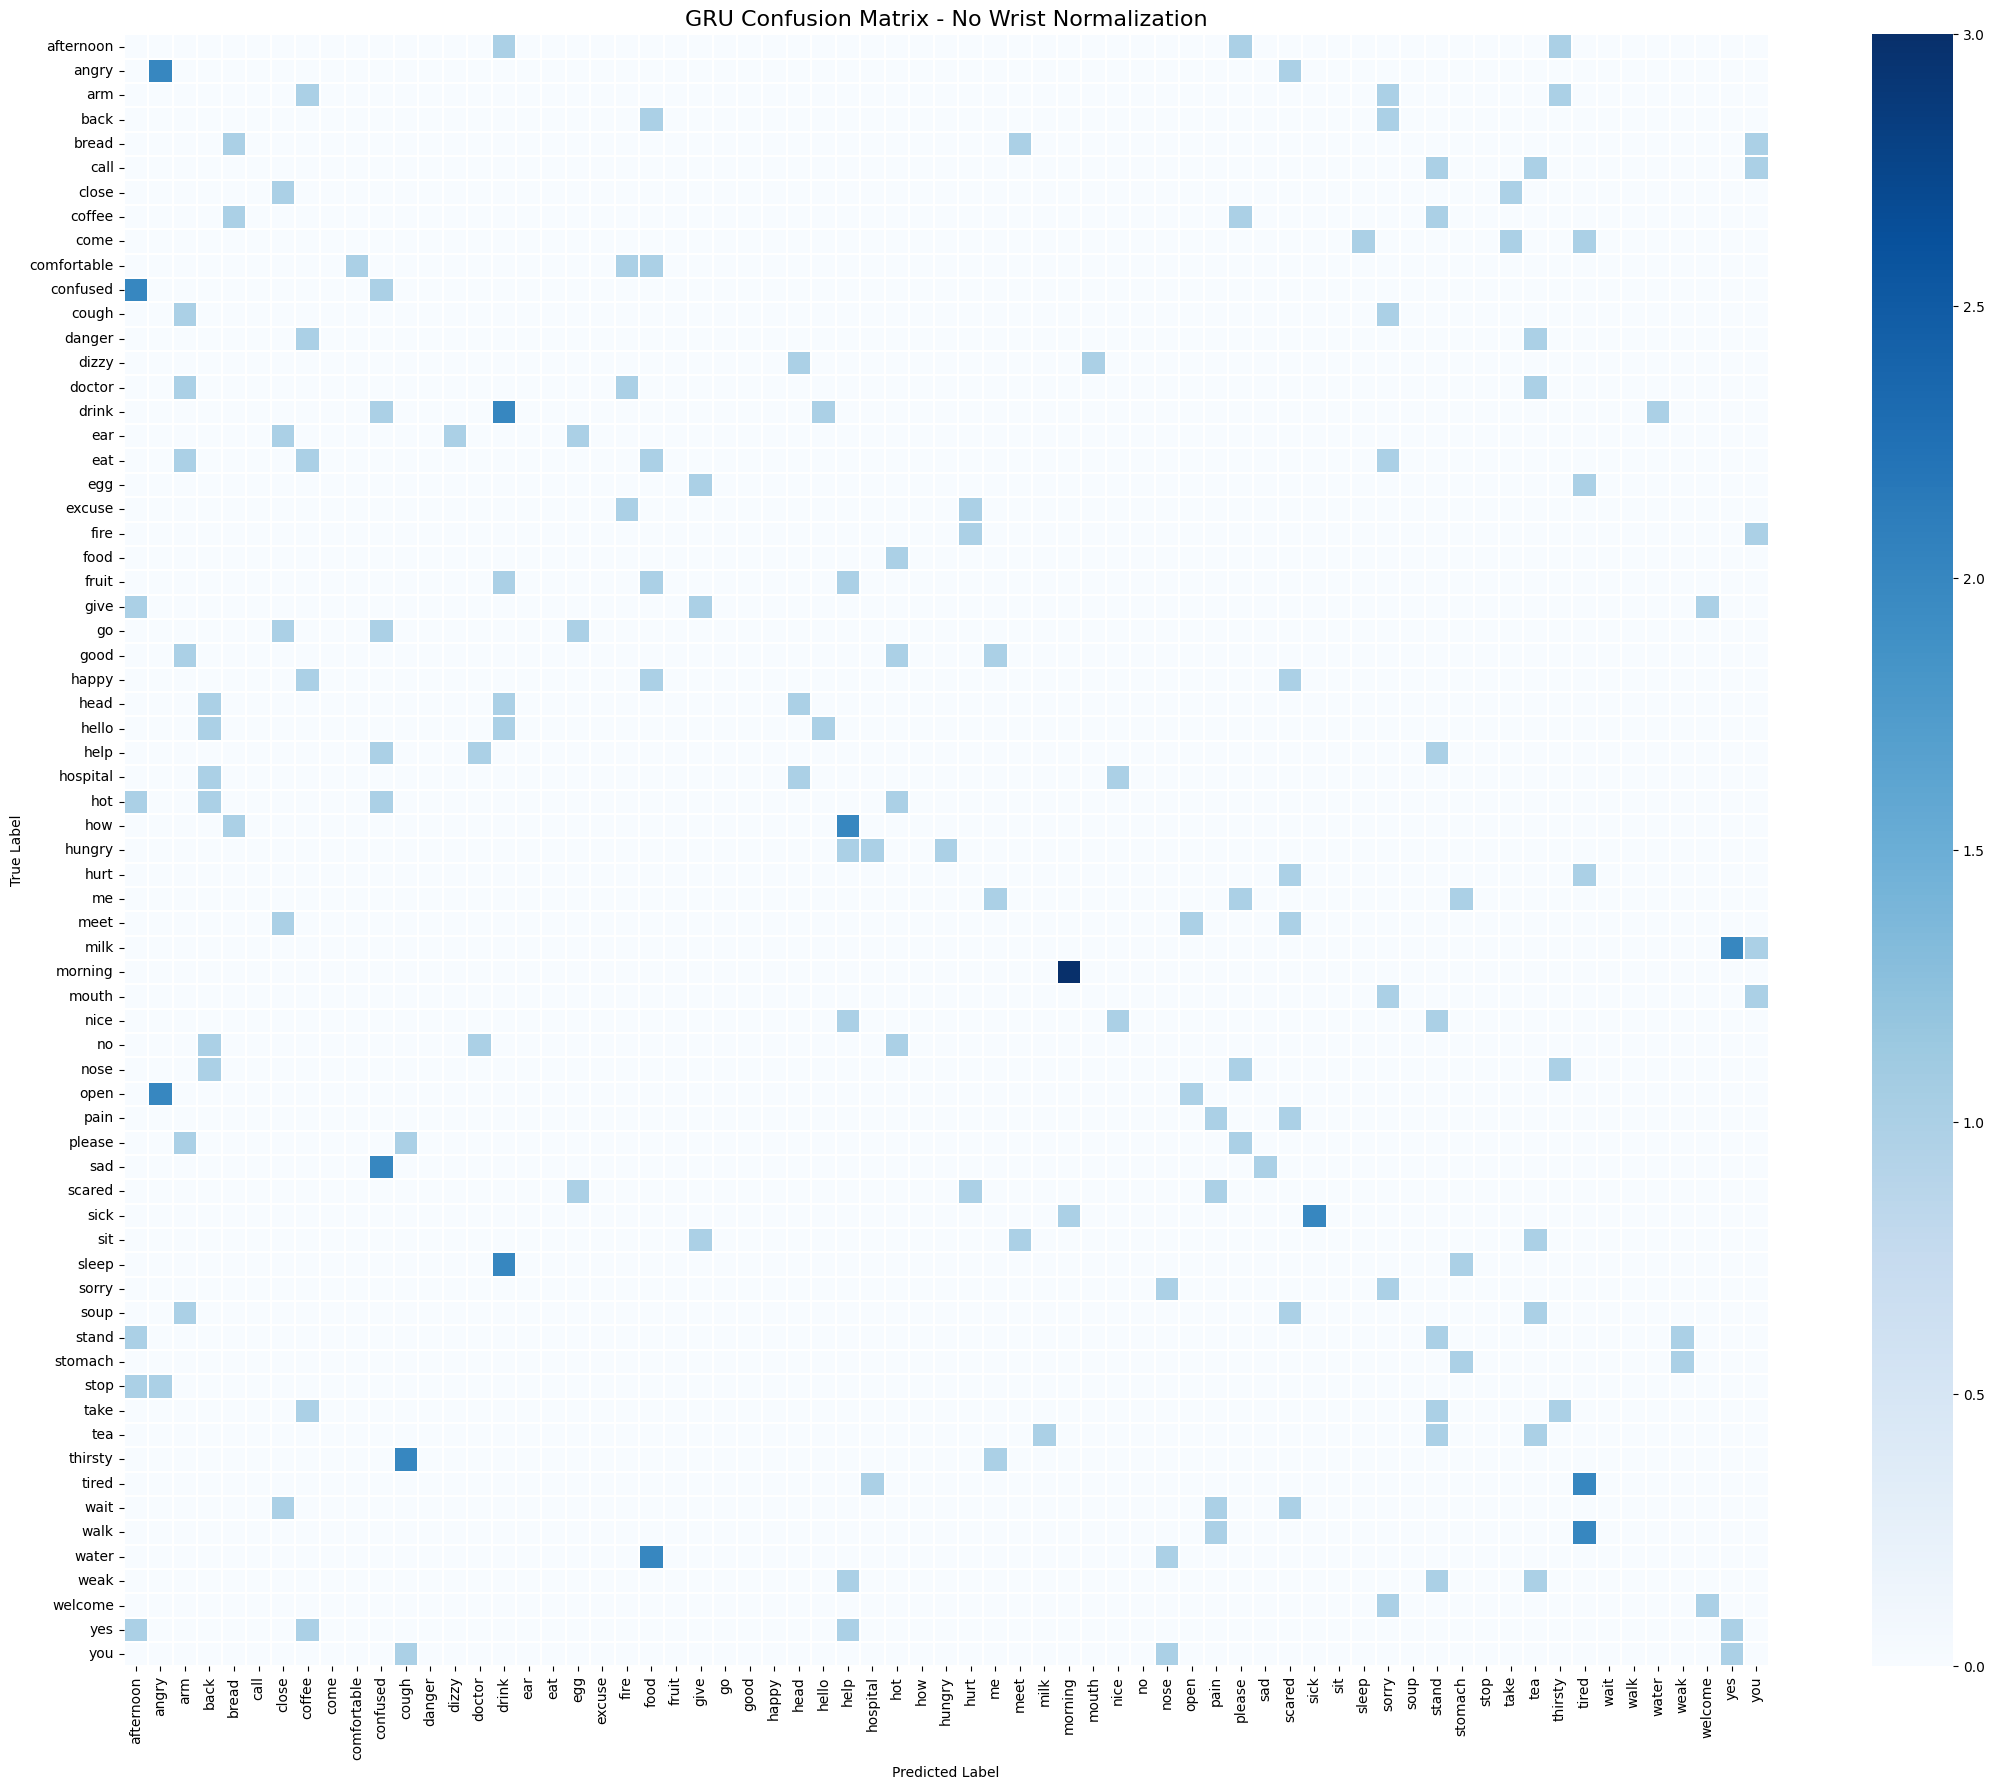


✅ Manual Accuracy Check
Accuracy Score: 0.1693
Accuracy Score (%): 16.93%


In [31]:
# ============================================================
# STAGE 9: EVALUATE BEST GRU MODEL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("=" * 60)
print("📊 EVALUATING BEST GRU MODEL")
print("=" * 60)

# Load best saved model
best_model_path = f"{MODEL_SAVE_DIR}/best_gru_no_wrist_norm.keras"
best_gru_model = load_model(best_model_path)

print(f"✅ Loaded best model from: {best_model_path}")

# Evaluate on test set
test_loss, test_accuracy = best_gru_model.evaluate(X_test, y_test, verbose=1)

print("\n✅ TEST RESULTS")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy (%): {test_accuracy * 100:.2f}%")

# Predictions
y_pred_probs = best_gru_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("\n" + "=" * 60)
print("📋 CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
)

print(report)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(22, 18))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=0.2
)

plt.title("GRU Confusion Matrix - No Wrist Normalization", fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Top-level accuracy check
manual_accuracy = accuracy_score(y_true, y_pred)

print("\n✅ Manual Accuracy Check")
print(f"Accuracy Score: {manual_accuracy:.4f}")
print(f"Accuracy Score (%): {manual_accuracy * 100:.2f}%")

# Building BiLSTM + Attention Model

In [32]:
# ============================================================
# STAGE 10: BUILD BiLSTM + ATTENTION MODEL
# ============================================================

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Bidirectional, LSTM, Dense, Dropout,
    BatchNormalization, Layer
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Custom Attention Layer
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        score = tf.keras.backend.tanh(tf.keras.backend.dot(inputs, self.W) + self.b)
        attention_weights = tf.keras.backend.softmax(score, axis=1)
        context_vector = inputs * attention_weights
        context_vector = tf.keras.backend.sum(context_vector, axis=1)
        return context_vector


print("=" * 60)
print("🧠 BUILDING BiLSTM + ATTENTION MODEL")
print("=" * 60)

inputs = Input(shape=(60, 378))

x = Bidirectional(
    LSTM(
        128,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    )
)(inputs)

x = BatchNormalization()(x)

x = Bidirectional(
    LSTM(
        64,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    )
)(x)

x = BatchNormalization()(x)

x = AttentionLayer()(x)

x = Dense(128, activation="relu", kernel_regularizer=l2(0.001))(x)
x = Dropout(0.4)(x)

x = Dense(64, activation="relu", kernel_regularizer=l2(0.001))(x)
x = Dropout(0.3)(x)

outputs = Dense(num_classes, activation="softmax")(x)

bilstm_attention_model = Model(inputs, outputs)

bilstm_attention_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_attention_model.summary()

print("\n✅ BiLSTM + Attention model built successfully")

🧠 BUILDING BiLSTM + ATTENTION MODEL


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 60, 378)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 60, 256)        │       519,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 60, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 128)            │           188 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 67)             │         4,355 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 714,367 (2.73 MB)

 Trainable params: 713,599 (2.72 MB)

 Non-trainable params: 768 (3.00 KB)


✅ BiLSTM + Attention model built successfully


In [33]:
# ============================================================
# STAGE 11: TRAIN BiLSTM + ATTENTION MODEL
# ============================================================

print("=" * 60)
print("🚀 TRAINING BiLSTM + ATTENTION MODEL")
print("=" * 60)

checkpoint_path = f"{MODEL_SAVE_DIR}/best_bilstm_attention_no_wrist_norm.keras"

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

history_bilstm_attention = bilstm_attention_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print("\n✅ BiLSTM + Attention training complete")
print(f"Best model saved to: {checkpoint_path}")

🚀 TRAINING BiLSTM + ATTENTION MODEL
Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.0233 - loss: 5.9311
Epoch 1: val_accuracy improved from None to 0.02116, saving model to /content/drive/MyDrive/SignLanguage_Dataset/models_v2/best_bilstm_attention_no_wrist_norm.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SignLanguage_Dataset/models_v2/best_bilstm_attention_no_wrist_norm.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 658ms/step - accuracy: 0.0230 - loss: 5.8217 - val_accuracy: 0.0212 - val_loss: 5.3745 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.0223 - loss: 5.3888
Epoch 2: val_accuracy did not improve from 0.02116
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 597ms/step - accuracy: 0.0212 - loss: 5.4101 - val_accuracy: 0.0212 - val_loss: 5.2270 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.0218 - loss: 5.3059
Epoch 3: val_accuracy did not improve from 0.02116
36/36 ━━━━━━━━━━━━━━━

📊 EVALUATING BEST BiLSTM + ATTENTION MODEL
✅ Loaded best model from:
/content/drive/MyDrive/SignLanguage_Dataset/models_v2/best_bilstm_attention_no_wrist_norm.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.1958 - loss: 3.6078

✅ TEST RESULTS
Test Loss: 3.6078
Test Accuracy: 0.1958
Test Accuracy (%): 19.58%
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 425ms/step

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

   afternoon       0.00      0.00      0.00         3
       angry       0.75      1.00      0.86         3
         arm       0.00      0.00      0.00         3
        back       0.00      0.00      0.00         2
       bread       0.14      0.33      0.20         3
        call       0.00      0.00      0.00         3
       close       1.00      0.50      0.67         2
      coffee       0.00      0.00      0.00         3
        come       0.00      0.00      0.00         3
 comfortable       0.14      0.33      0.20         3
    confused       0

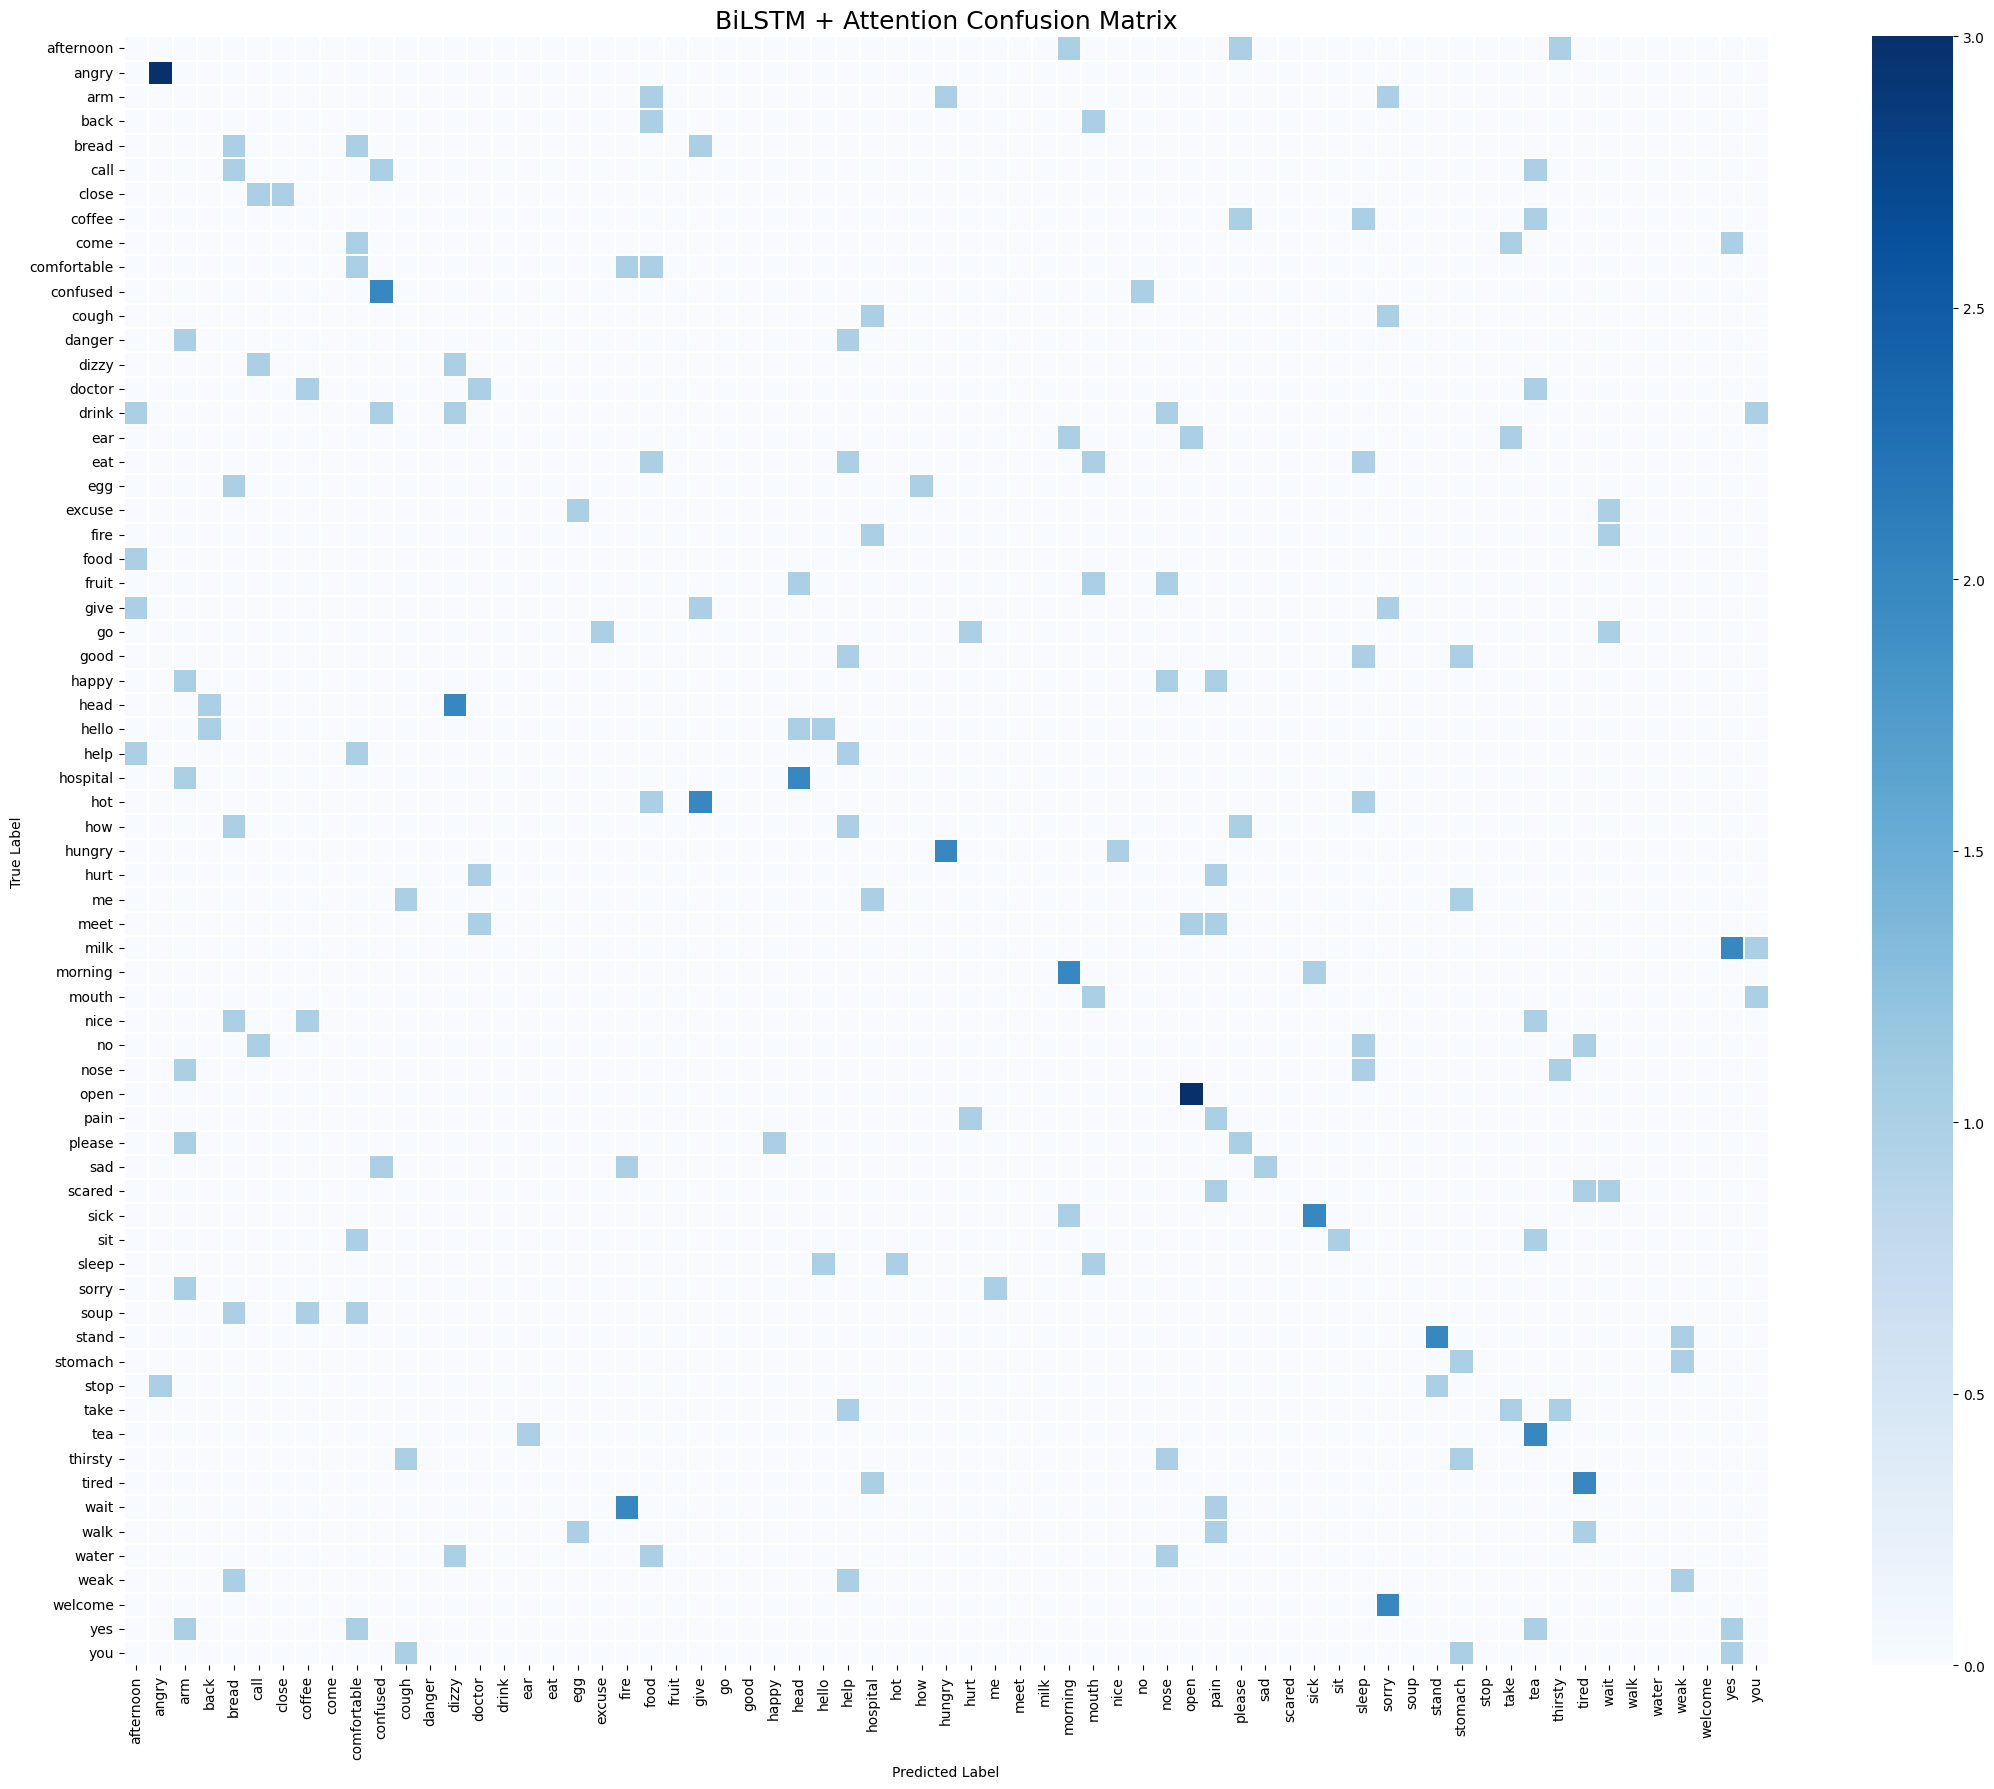


✅ Manual Accuracy Check
Accuracy Score: 0.1958
Accuracy Score (%): 19.58%


In [34]:
# ============================================================
# STAGE 12: EVALUATE BEST BiLSTM + ATTENTION MODEL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# ============================================================
# CUSTOM ATTENTION LAYER (REQUIRED FOR LOADING MODEL)
# ============================================================

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        score = tf.keras.backend.tanh(
            tf.keras.backend.dot(inputs, self.W) + self.b
        )

        attention_weights = tf.keras.backend.softmax(score, axis=1)

        context_vector = inputs * attention_weights
        context_vector = tf.keras.backend.sum(context_vector, axis=1)

        return context_vector


# ============================================================
# LOAD BEST MODEL
# ============================================================

print("=" * 60)
print("📊 EVALUATING BEST BiLSTM + ATTENTION MODEL")
print("=" * 60)

best_model_path = f"{MODEL_SAVE_DIR}/best_bilstm_attention_no_wrist_norm.keras"

best_model = load_model(
    best_model_path,
    custom_objects={"AttentionLayer": AttentionLayer}
)

print(f"✅ Loaded best model from:\n{best_model_path}")


# ============================================================
# TEST ACCURACY
# ============================================================

test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\n✅ TEST RESULTS")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy (%): {test_accuracy * 100:.2f}%")


# ============================================================
# PREDICTIONS
# ============================================================

y_pred_probs = best_model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("📋 CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
)

print(report)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(22, 18))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=0.2
)

plt.title(
    "BiLSTM + Attention Confusion Matrix",
    fontsize=18
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


# ============================================================
# MANUAL ACCURACY CHECK
# ============================================================

manual_accuracy = accuracy_score(y_true, y_pred)

print("\n✅ Manual Accuracy Check")
print(f"Accuracy Score: {manual_accuracy:.4f}")
print(f"Accuracy Score (%): {manual_accuracy * 100:.2f}%")

Testing with filtering only 30 words

In [35]:
# ============================================================
# STAGE 13: CREATE TOP-30 CLASS DATASET
# ============================================================

import numpy as np
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical

TOP_N_CLASSES = 30

# Load full preprocessed data
X_full = np.load(f"{PREPROCESSED_DIR}/X_no_wrist_norm.npy")
y_full = np.load(f"{PREPROCESSED_DIR}/y_no_wrist_norm.npy", allow_pickle=True)

# Get top N classes
class_counts = pd.Series(y_full).value_counts()
top_classes = class_counts.head(TOP_N_CLASSES).index

print("=" * 60)
print("📊 TOP-30 SELECTED CLASSES")
print("=" * 60)
print(class_counts.head(TOP_N_CLASSES))

# Filter dataset
mask = np.isin(y_full, top_classes)

X_top = X_full[mask]
y_top = y_full[mask]

print("\n✅ TOP-30 DATASET CREATED")
print(f"X_top shape: {X_top.shape}")
print(f"y_top shape: {y_top.shape}")
print(f"Classes: {len(np.unique(y_top))}")

# Encode labels
top_label_encoder = LabelEncoder()
y_encoded = top_label_encoder.fit_transform(y_top)
num_classes_top = len(top_label_encoder.classes_)

y_categorical = to_categorical(y_encoded, num_classes=num_classes_top)

# Train/Val/Test split: 60/20/20
X_train_top, X_temp_top, y_train_top, y_temp_top, y_train_int_top, y_temp_int_top = train_test_split(
    X_top,
    y_categorical,
    y_encoded,
    test_size=0.40,
    stratify=y_encoded,
    random_state=42
)

X_val_top, X_test_top, y_val_top, y_test_top, y_val_int_top, y_test_int_top = train_test_split(
    X_temp_top,
    y_temp_top,
    y_temp_int_top,
    test_size=0.50,
    stratify=y_temp_int_top,
    random_state=42
)

print("\n✅ SPLIT COMPLETE")
print(f"Train:      {X_train_top.shape}, {y_train_top.shape}")
print(f"Validation: {X_val_top.shape}, {y_val_top.shape}")
print(f"Test:       {X_test_top.shape}, {y_test_top.shape}")

# Class weights
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int_top),
    y=y_train_int_top
)

class_weights_top = dict(zip(np.unique(y_train_int_top), class_weight_values))

print("\n✅ Class weights created")

# Save label encoder
with open(f"{PREPROCESSED_DIR}/top30_label_encoder.pkl", "wb") as f:
    pickle.dump(top_label_encoder, f)

📊 TOP-30 SELECTED CLASSES
drink       22
eat         18
yes         17
hot         17
give        16
go          16
me          16
wait        16
sad         16
how         16
tired       16
you         16
good        16
no          16
water       15
please      15
thirsty     15
fruit       15
tea         15
call        15
walk        15
sick        15
help        15
hospital    15
angry       15
doctor      15
morning     14
nice        14
head        14
nose        14
Name: count, dtype: int64

✅ TOP-30 DATASET CREATED
X_top shape: (470, 60, 378)
y_top shape: (470,)
Classes: 30

✅ SPLIT COMPLETE
Train:      (282, 60, 378), (282, 30)
Validation: (94, 60, 378), (94, 30)
Test:       (94, 60, 378), (94, 30)

✅ Class weights created


In [36]:
# ============================================================
# STAGE 14: BUILD TOP-30 BiLSTM + ATTENTION MODEL
# ============================================================

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Bidirectional, LSTM, Dense, Dropout,
    BatchNormalization, Layer
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        score = tf.keras.backend.tanh(tf.keras.backend.dot(inputs, self.W) + self.b)
        attention_weights = tf.keras.backend.softmax(score, axis=1)
        context_vector = inputs * attention_weights
        context_vector = tf.keras.backend.sum(context_vector, axis=1)
        return context_vector


print("=" * 60)
print("🧠 BUILDING TOP-30 BiLSTM + ATTENTION MODEL")
print("=" * 60)

inputs = Input(shape=(60, 378))

x = Bidirectional(
    LSTM(
        128,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    )
)(inputs)

x = BatchNormalization()(x)

x = Bidirectional(
    LSTM(
        64,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    )
)(x)

x = BatchNormalization()(x)

x = AttentionLayer()(x)

x = Dense(128, activation="relu", kernel_regularizer=l2(0.001))(x)
x = Dropout(0.4)(x)

x = Dense(64, activation="relu", kernel_regularizer=l2(0.001))(x)
x = Dropout(0.3)(x)

outputs = Dense(num_classes_top, activation="softmax")(x)

top30_model = Model(inputs, outputs)

top30_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

top30_model.summary()

print("\n✅ Top-30 BiLSTM + Attention model built")

🧠 BUILDING TOP-30 BiLSTM + ATTENTION MODEL


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 60, 378)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 60, 256)        │       519,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 60, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 60, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_1               │ (None, 128)            │           188 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 711,962 (2.72 MB)

 Trainable params: 711,194 (2.71 MB)

 Non-trainable params: 768 (3.00 KB)


✅ Top-30 BiLSTM + Attention model built


In [37]:
# ============================================================
# STAGE 15: TRAIN TOP-30 MODEL
# ============================================================

print("=" * 60)
print("🚀 TRAINING TOP-30 BiLSTM + ATTENTION MODEL")
print("=" * 60)

checkpoint_path = f"{MODEL_SAVE_DIR}/best_top30_bilstm_attention.keras"

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

history_top30 = top30_model.fit(
    X_train_top,
    y_train_top,
    validation_data=(X_val_top, y_val_top),
    epochs=100,
    batch_size=16,
    class_weight=class_weights_top,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print("\n✅ Top-30 training complete")
print(f"Best model saved to: {checkpoint_path}")

🚀 TRAINING TOP-30 BiLSTM + ATTENTION MODEL
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.0332 - loss: 5.2917
Epoch 1: val_accuracy improved from None to 0.05319, saving model to /content/drive/MyDrive/SignLanguage_Dataset/models_v2/best_top30_bilstm_attention.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SignLanguage_Dataset/models_v2/best_top30_bilstm_attention.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 729ms/step - accuracy: 0.0426 - loss: 5.1912 - val_accuracy: 0.0532 - val_loss: 4.7438 - learning_rate: 0.0010
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.0655 - loss: 4.8369
Epoch 2: val_accuracy did not improve from 0.05319
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 626ms/step - accuracy: 0.0461 - loss: 4.7907 - val_accuracy: 0.0426 - val_loss: 4.5789 - learning_rate: 0.0010
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.0260 - loss: 4.7044
Epoch 3: val_accuracy improved from 0.05319 to 0.07447, saving model to /content/

📊 EVALUATING TOP-30 MODEL
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 194ms/step - accuracy: 0.2660 - loss: 3.2843

✅ TOP-30 TEST RESULTS
Test Loss: 3.2843
Test Accuracy: 0.2660
Test Accuracy (%): 26.60%


2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 893ms/step

📋 TOP-30 CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.75      1.00      0.86         3
        call       0.00      0.00      0.00         3
      doctor       0.00      0.00      0.00         3
       drink       0.00      0.00      0.00         4
         eat       0.33      0.25      0.29         4
       fruit       0.00      0.00      0.00         3
        give       1.00      0.33      0.50         3
          go       0.33      0.67      0.44         3
        good       0.00      0.00      0.00         3
        head       0.40      0.67      0.50         3
        help       0.00      0.00      0.00         3
    hospital       0.00      0.00      0.00         3
         hot       0.50      0.67      0.57         3
         how       0.50      0.25      0.33         4
          me       0.40      0.67      0.50         3
     morning       0.33      0.33      0.33         3
        ni

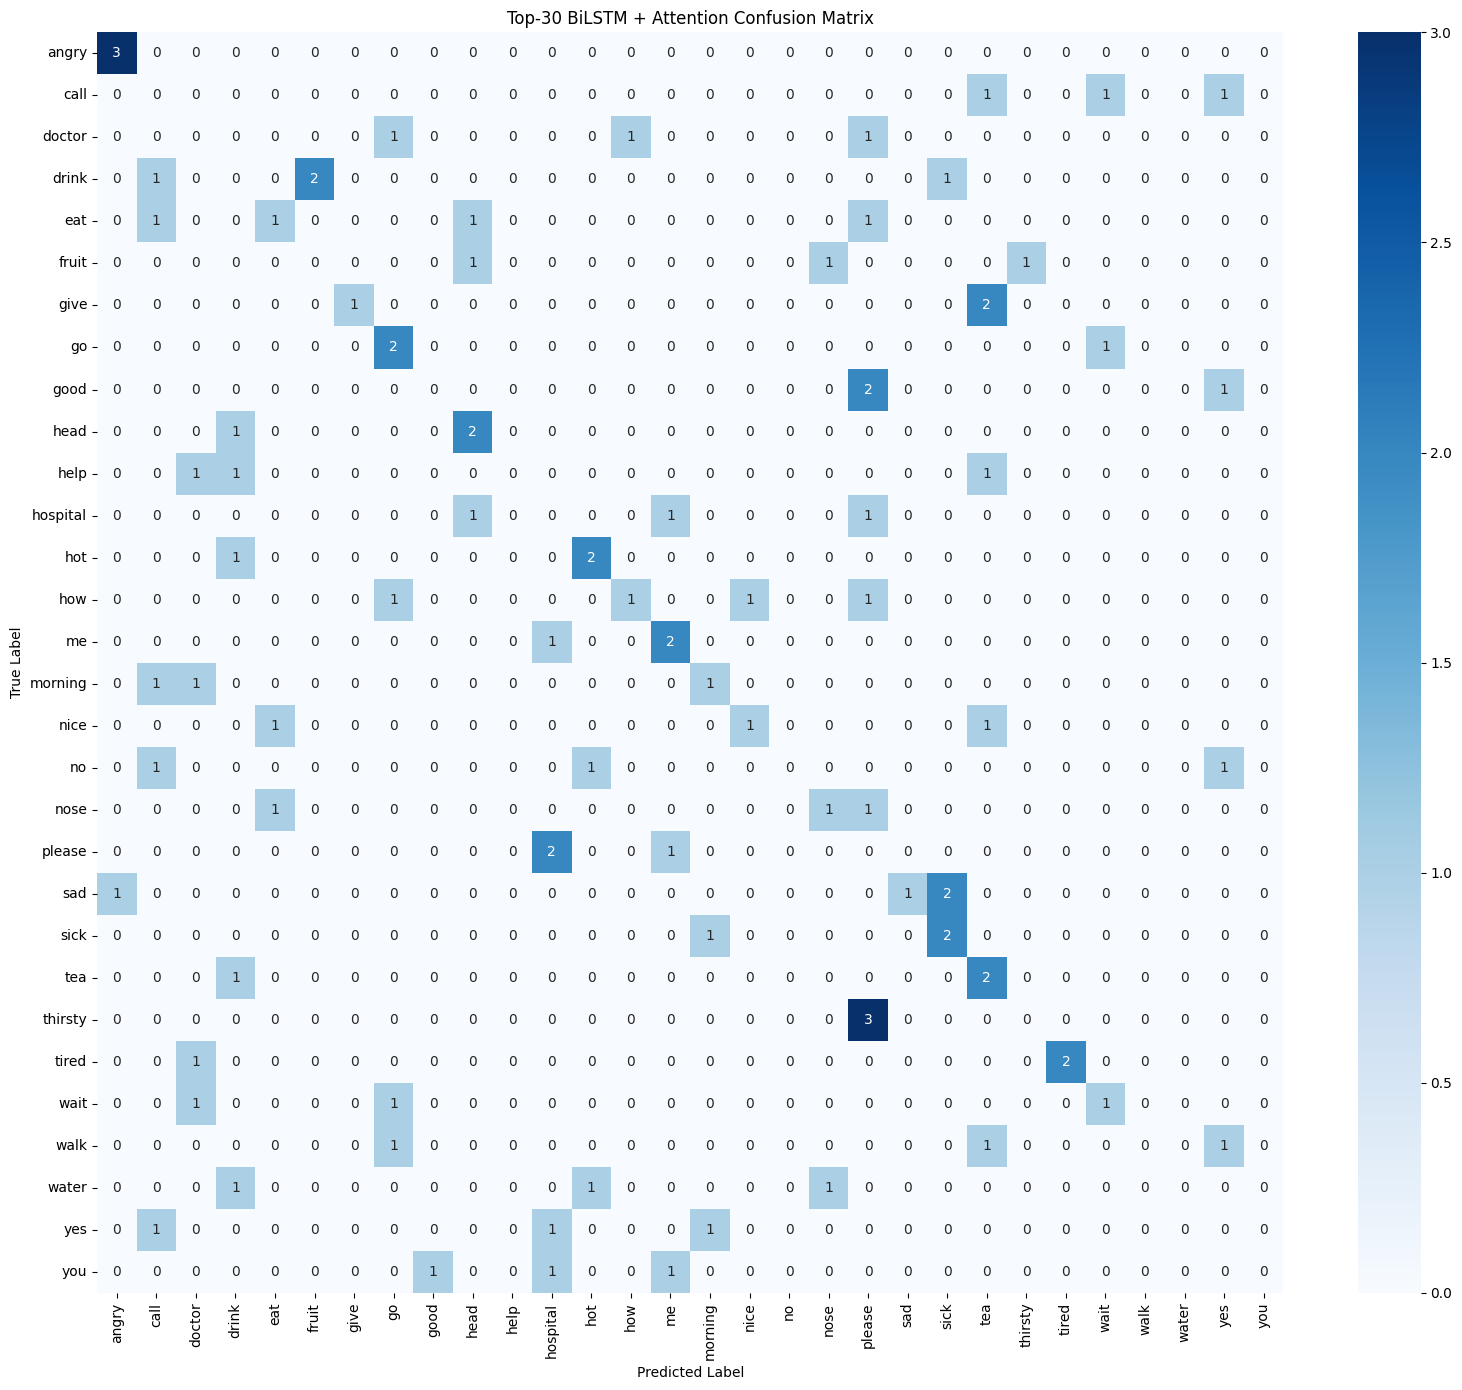


✅ Manual Accuracy Check
Accuracy Score: 0.2660
Accuracy Score (%): 26.60%


In [38]:
# ============================================================
# STAGE 16: EVALUATE TOP-30 MODEL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("=" * 60)
print("📊 EVALUATING TOP-30 MODEL")
print("=" * 60)

best_top30_model = load_model(
    f"{MODEL_SAVE_DIR}/best_top30_bilstm_attention.keras",
    custom_objects={"AttentionLayer": AttentionLayer}
)

test_loss, test_accuracy = best_top30_model.evaluate(
    X_test_top,
    y_test_top,
    verbose=1
)

print("\n✅ TOP-30 TEST RESULTS")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy (%): {test_accuracy * 100:.2f}%")

# Predictions
y_pred_probs = best_top30_model.predict(X_test_top)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_top, axis=1)

print("\n" + "=" * 60)
print("📋 TOP-30 CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=top_label_encoder.classes_,
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=top_label_encoder.classes_,
    yticklabels=top_label_encoder.classes_,
    annot=True,
    fmt="d"
)

plt.title("Top-30 BiLSTM + Attention Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

manual_accuracy = accuracy_score(y_true, y_pred)

print("\n✅ Manual Accuracy Check")
print(f"Accuracy Score: {manual_accuracy:.4f}")
print(f"Accuracy Score (%): {manual_accuracy * 100:.2f}%")